Building likelihood maps for a set of representative images.

> TODO: use images from dataset and superimpose the bounding boxes on them

In [1]:
from retinotopy import *

Running on GPU :  NVIDIA GeForce RTX 3060 #GPU= 1
---------------------------------------------------------------------------------------------------
On date 2024-05-24, Running learning on host DESKTOP-27VNO0E with device cuda, pytorch==2.2.0+cu121
---------------------------------------------------------------------------------------------------
Welcome on Linux-5.10.16.3-microsoft-standard-WSL2-x86_64-with-glibc2.35
Random seed 1998 has been set.


In [2]:
# The dataset to import images from

data_set_type = 'full'
args = Params()
args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
args.folders = ['val'] # type of images to use

args.do_saccade = True
args.do_resize = False
args.do_mask = False
args.do_polar = False

## doing the computations

In [ ]:
pos_pred_zero = ((args.resolution[0]*args.resolution[1])//2)
retino_grid = get_grid(args).unsqueeze(0).to(device)
print(args)

print('Lets go last 1 uk manu! ')
annotations = None
#for model_data_set_type in data_set_types:
for model_data_set_type in ['bbox', 'raw']:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    
    for model_name in  ['resnet101']:
    #for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')

        best_tresh = 0.2 if model_name == 'resnet18' else 0.1
        
        for do_polar in [True, False]:

            do_polar = do_polar if model_data_set_type != 'raw' else False

            args.do_polar = do_polar
            print(f'{args.do_polar=}')

            df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + f'_map_paper_full_grid_0_5.parquet'
            print(df_filename)
            
            if os.path.isfile(df_filename):
                continue
            else:
                df_map = None
                
                print(50*'.')
                
                model_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + '.pt' if model_data_set_type != 'raw' else None
                
                model = load_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()
                
                if annotations is None:
                    annotations = get_annotation('csv')
                    df_filename_cam = get_filename(data_cache, datetag, 'raw', model_name, False) + f'_complete_gradcam.parquet'
                    annotations_cam = pd.read_parquet(df_filename_cam)

                with torch.no_grad():
                    BUG?? image_datasets = image_datasets_transforms(args, shuffle=False, verbose=False)
                    #for indice in tqdm(indices):
                        #indice = int(indice)
                        #images, label = image_datasets[indice]
                    
                    for i_image, (images, label) in tqdm(enumerate(image_datasets)):

                        image_name = image_datasets.samples[i_image][0].split('/')[-1].split('.')[0]
                        
                        ground_true_indices, three_points, ground_true, origin_size = get_ground_true(args, image_name, annotations, 'Imagenet')
                        
                        if ground_true.min() == 0.0:
                            
                            since = time.time()
                            

                            
                            images = images.to(device, non_blocking=True)

                            heat_map = model(images)

               
    
                            _, pred_zero = torch.max(heat_map[pos_pred_zero].data, 0) # get the predicted label and its likelihood within the all image
    
                            pred_grid = torch.argmax(heat_map, dim=1) # get the most frequent predicted label (top1 and top5)
                            best_pred = torch.argmax(torch.bincount(pred_grid)).item()
                            best_pred_5 = label if label in get_top_indices(torch.bincount(pred_grid), 5) else best_pred
            
                            
            
                            sum = torch.argmax(torch.sum(heat_map, dim=0)).item() # get the label predict when we sum the evidence on all fixation points or inside the box
                            sum_in = torch.argmax(torch.sum(heat_map[ground_true_indices[0]], dim=0)).item()
    
                            
    
                            heatmap_soft = torch.nn.functional.softmax(heat_map, dim=1)
    
                            likelihood_zero = torch.max(heatmap_soft[pos_pred_zero].data).item()
                            
                            heatmap_prior = heatmap_soft[:, label]
                            
                            mid_point, in_point, ext_point = get_like_point(heatmap_prior, args.resolution, three_points)

                            
    
                            arg_max_prior = torch.argmax(heatmap_prior)
                            position_prior = (arg_max_prior.item()//min(args.resolution), arg_max_prior.item()%min(args.resolution))
                            _, pred_prior = torch.max(heat_map[arg_max_prior].data, 0) # pred at pov_max_prior
                            likelihood_prior = torch.max(heatmap_prior).item()

                            arg_min_prior = torch.argmin(heatmap_prior)
                            position_min = (arg_min_prior.item()//min(args.resolution), arg_min_prior.item()%min(args.resolution))
                            _, pred_prior_min = torch.max(heat_map[arg_min_prior].data, 0) # pred at pov_min_prior
                            likelihood_prior_min = torch.min(heatmap_prior).item()

                            midle_points = get_points_between(position_prior, position_min)
                            
                            midle_point = midle_points[len(midle_points)//2]
                            arg_mid_prior = (midle_point[0]*args.resolution[0])+midle_point[1]
                            _, pred_prior_mid = torch.max(heat_map[arg_mid_prior].data, 0) # pred at pov_mid_prior
                            likelihood_prior_mid = heatmap_prior[arg_mid_prior].item()
                        
    
                            arg_max_no_prior = torch.argmax(heat_map)
                            pred_no_prior = (arg_max_no_prior%1000).item()
                            likelihood_no_prior = heatmap_soft[(arg_max_no_prior//1000),pred_no_prior].item()

    
                            out_heat = th_delete(heatmap_prior, ground_true_indices[0])
                            
    
                            likelihood_out_max = torch.max(out_heat).item()
                            likelihood_in_max = torch.max(heatmap_prior[ground_true_indices[0]]).item()
    
                            likelihood_out_mean = torch.mean(out_heat).item()
                            likelihood_in_mean = torch.mean(heatmap_prior[ground_true_indices[0]]).item()
    
                            Iou = get_IoU(heatmap_prior.cpu(), ground_true.reshape(args.resolution[0]*args.resolution[1]))


                            if len(annotations_cam[annotations_cam['image_name']==image_name]['GradCam']) > 0:
                                ground_true_cam = cv2.resize(annotations_cam[annotations_cam['image_name']==image_name]['GradCam'].item().reshape(7,7), (args.resolution[1], args.resolution[0]), 
                                                           interpolation=cv2.INTER_LINEAR) > best_tresh
                                
                                Iou_cam = get_IoU(heatmap_prior.cpu(), ground_true_cam.reshape(args.resolution[0]*args.resolution[1]))
                            else:
                                Iou_cam = None
                                
                            PG = 1 if likelihood_in_max > likelihood_out_max else 0

                            dist = [euclidean_distance(position_prior, midle_point), euclidean_distance(position_prior, position_min)]
                            
                
                            df_map_ = pd.DataFrame({'ImageId':image_name, 'likelihood_in_max': likelihood_in_max, 'likelihood_out_max': likelihood_out_max, 'likelihood_prior_mid':likelihood_prior_mid,
                                                 'pred_zero':pred_zero.item(), 'pred_prior':pred_prior.item(), 'pred_prior_min':pred_prior_min.item(), 'pred_no_prior':pred_no_prior, 'best_pred':best_pred, 
                                                 'likelihood_prior':likelihood_prior, 'likelihood_zero':likelihood_zero, 'likelihood_no_prior':likelihood_no_prior, 'best_pred_5':best_pred_5, 
                                                 'likelihood_out_mean': likelihood_out_mean, 'likelihood_in_mean': likelihood_in_mean, 'pred_prior_mid':pred_prior_mid.item(),
                                                 'mid_point':mid_point.item(), 'in_point':in_point.item(), 'ext_point':ext_point.item(), 'Iou': [Iou], 'Iou_cam': [Iou_cam], 
                                                 'position_prior':[position_prior], 'position_min':[position_min], 'midle_point':[midle_point], 'likelihood_prior_min':likelihood_prior_min, 
                                                 'sum':sum,'sum_in':sum_in, 'time':time.time() - since, 'label':label, 'PG':PG, 'Distance_0': [dist[0]], 'Distance_1': [dist[1]]})
                            df_map = store_pandas(df_map, df_map_)

                            if torch.cuda.is_available(): torch.cuda.empty_cache()
                            

                    df_map.to_parquet(df_filename)   

            #imshow(images.cpu())
            #imshow(images[arg_max_prior].cpu())

## Analyse the data

In [4]:
def get_pandas(model_data_set_type, model_name):
    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, True) + f'_map_paper.parquet'

    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df_ret = pd.read_parquet(df_filename)


    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, False) + f'_map_paper.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df = pd.read_parquet(df_filename)

    df_filename = get_filename(data_cache, datetag, 'raw', model_name, False) + f'_map_paper.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df_raw = pd.read_parquet(df_filename)
    
        
    return df, df_ret, df_raw

model_data_set_type='full'
..................................................
df_filename='cached_data/2024-05-24_full_resnet18_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet18_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet18_cartesian_map_paper.parquet'


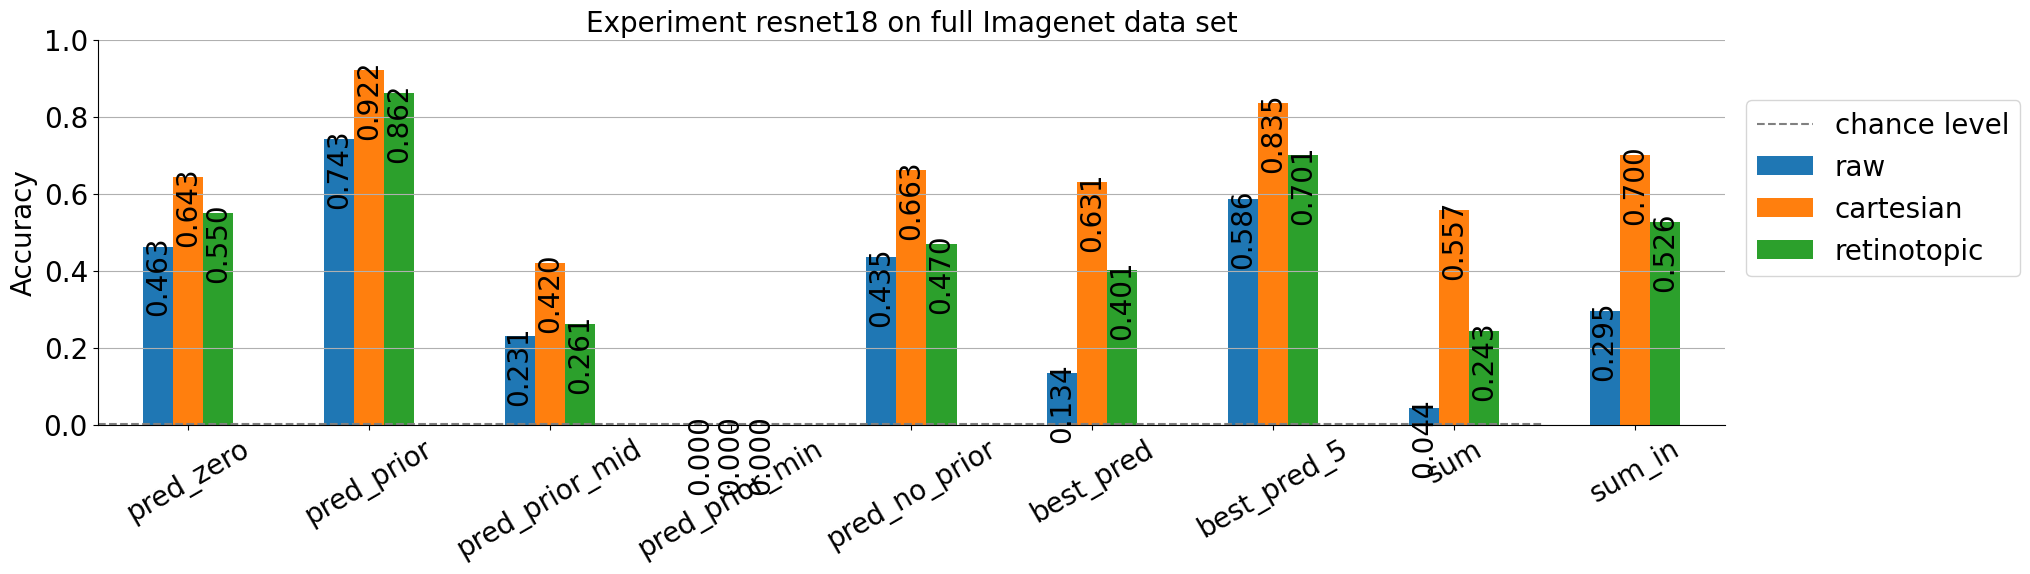

..................................................
df_filename='cached_data/2024-05-24_full_resnet50_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet50_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet50_cartesian_map_paper.parquet'


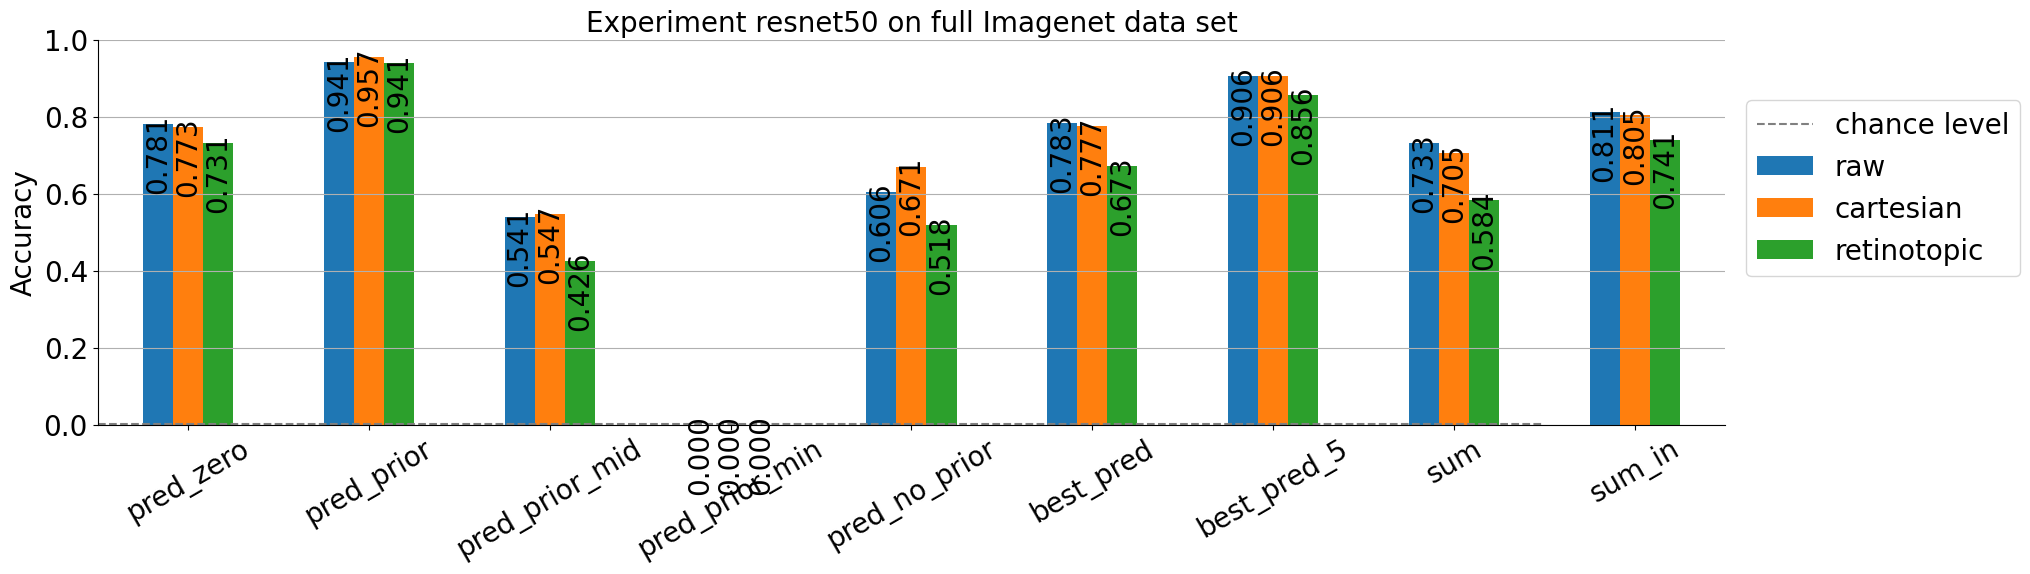

..................................................
df_filename='cached_data/2024-05-24_full_resnet101_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet101_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_paper.parquet'


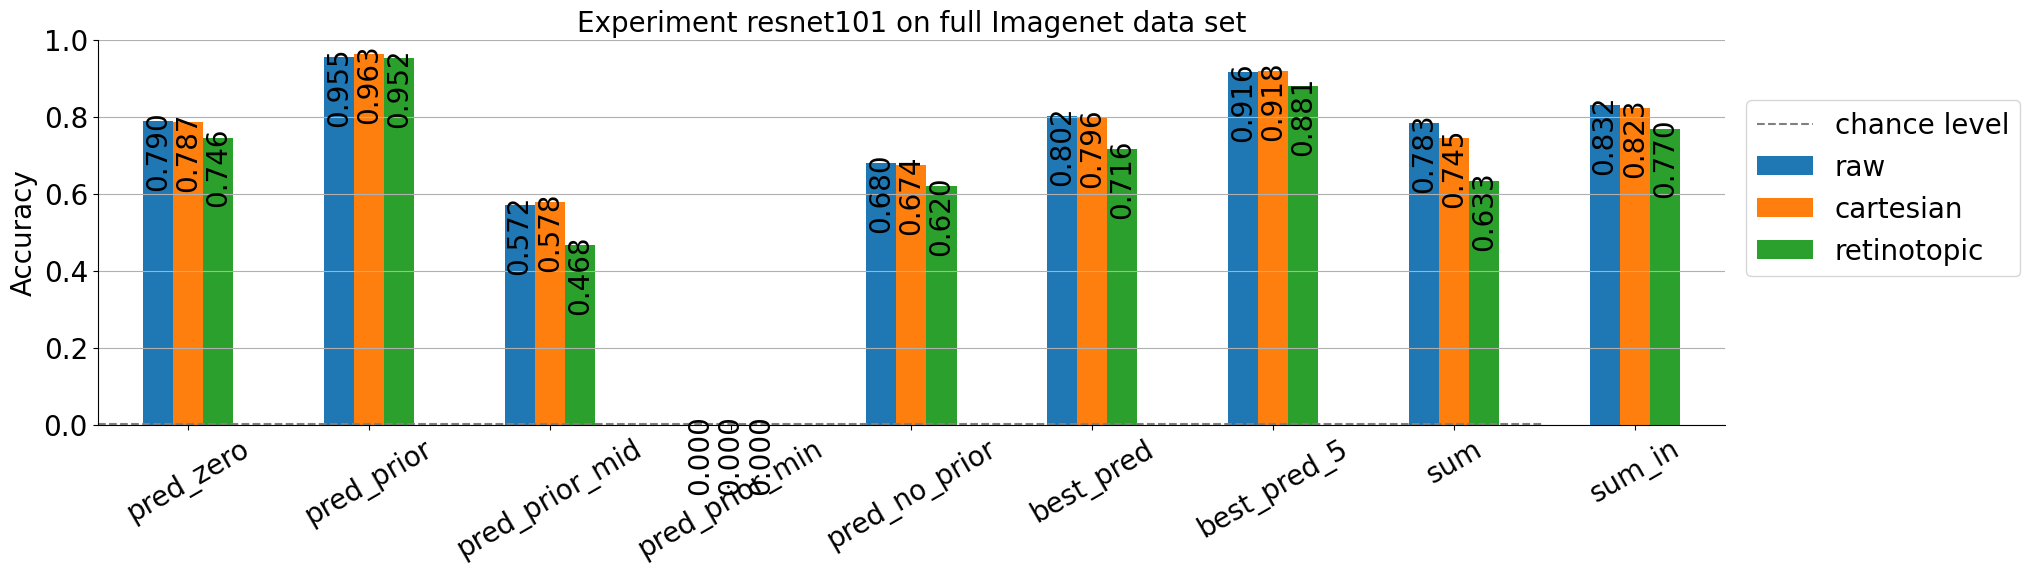

model_data_set_type='bbox'
..................................................
df_filename='cached_data/2024-05-24_bbox_resnet18_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet18_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet18_cartesian_map_paper.parquet'


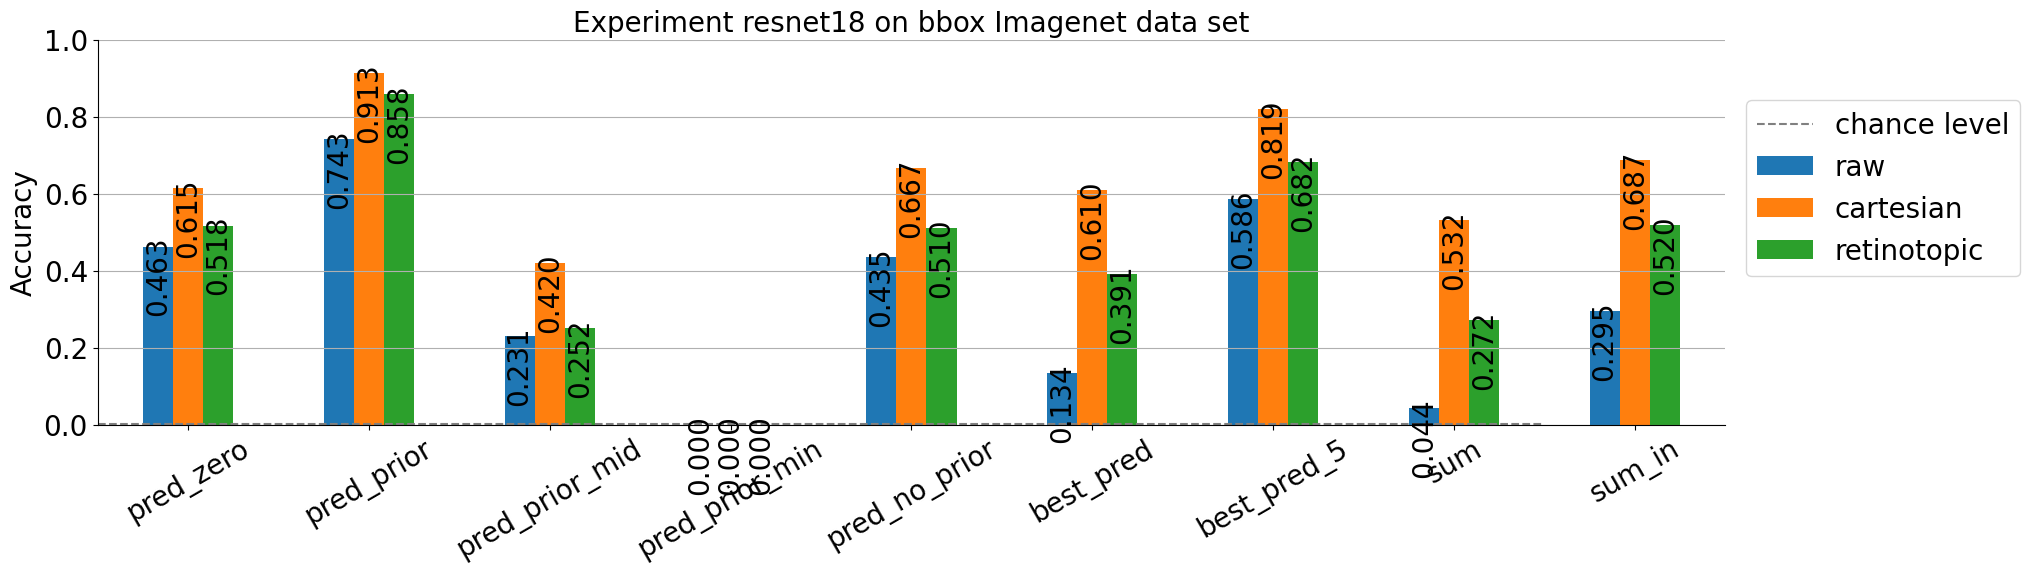

..................................................
df_filename='cached_data/2024-05-24_bbox_resnet50_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet50_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet50_cartesian_map_paper.parquet'


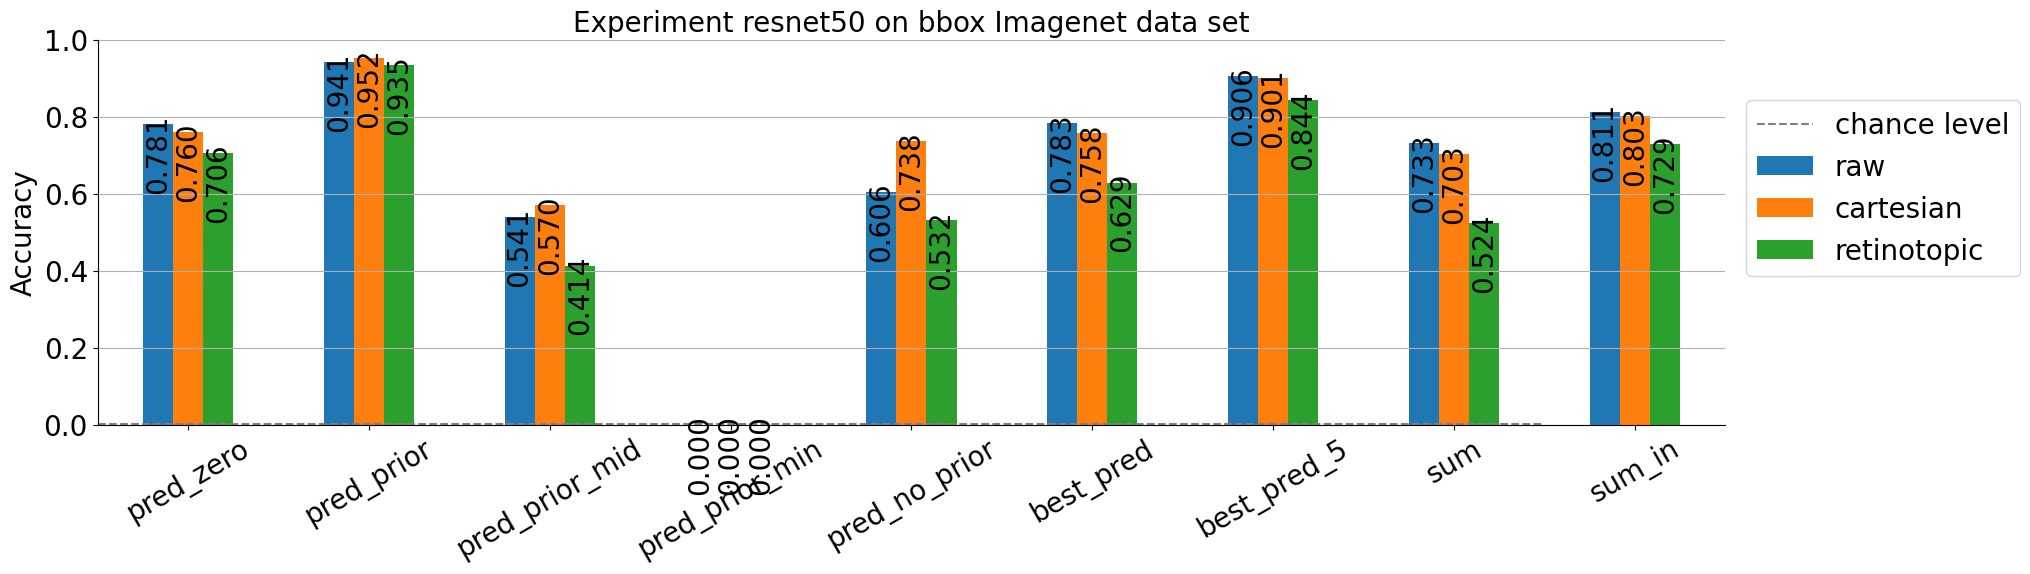

..................................................
df_filename='cached_data/2024-05-24_bbox_resnet101_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet101_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_paper.parquet'


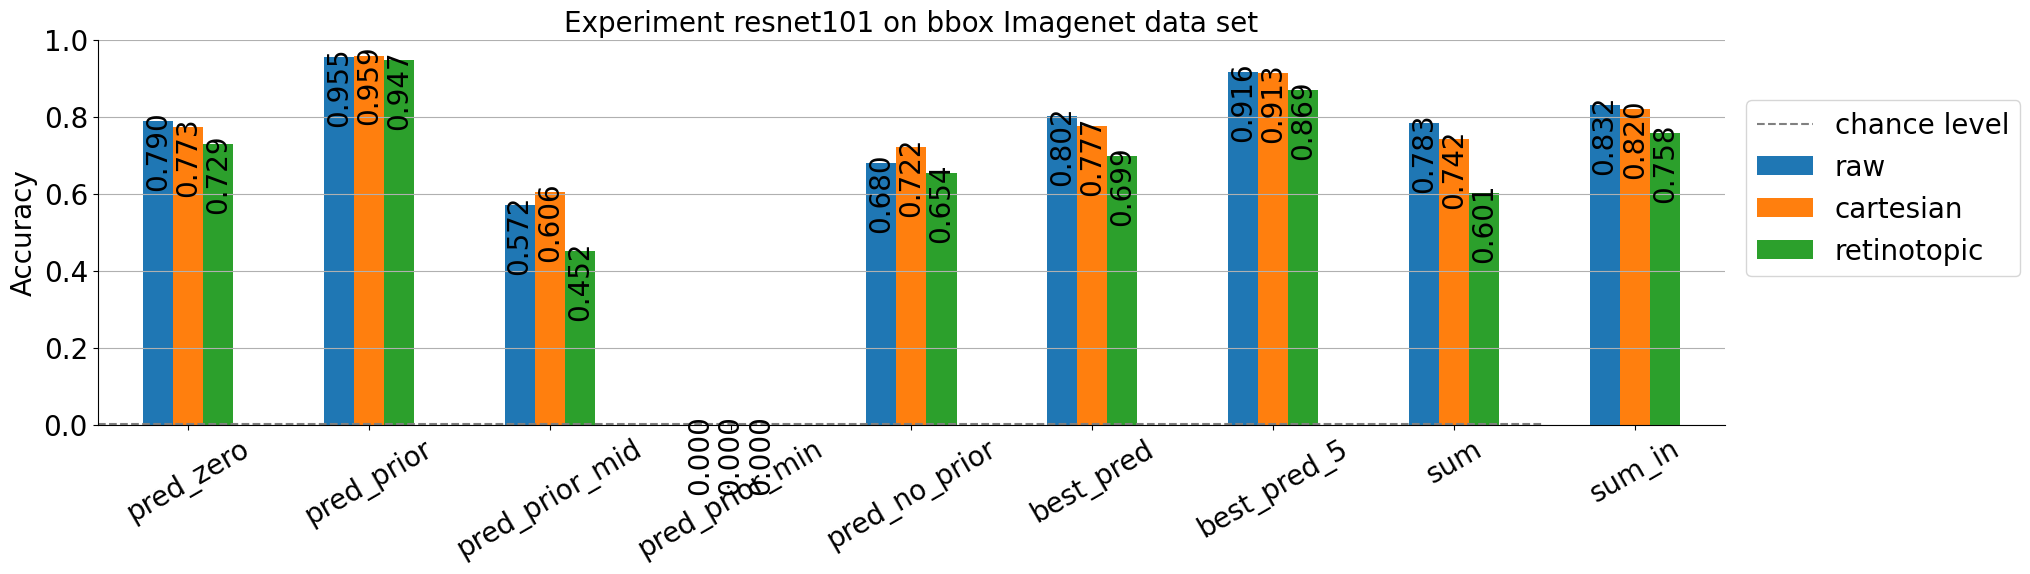

In [5]:
fig_width = 15
fontsize= 20

#for model_data_set_type in [ 'bbox']:
for model_data_set_type in ['full', 'bbox']:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    #for model_name in  ['resnet101']:
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)
                
        df_acc = pd.DataFrame({pred: {label: accuracy_score(df_[pred], df_["label"])
                                            for label, df_ in zip(['raw', 'cartesian', 'retinotopic'], [df_raw, df, df_ret])} 
                               for pred in ['pred_zero', 'pred_prior', 'pred_prior_mid', 'pred_prior_min', 'pred_no_prior', 'best_pred', 'best_pred_5', 'sum', 'sum_in']})
        
        ax = df_acc.T.plot.bar(rot=30, figsize=(fig_width*1.4, fig_width//3), fontsize=fontsize)
        ax.set_ylim(0, 1)
        ax.hlines(xmin=-.5, xmax=7.5, y=1/1000, ls='--', ec='gray', label='chance level')
        # https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html
        for container in ax.containers: ax.bar_label(container, padding=-50, color='black', fontsize=fontsize, fmt='%.3f', rotation=90)
        plt.legend(bbox_to_anchor=(1.19, .35), loc='lower right', fontsize=fontsize)
        ax.grid(which='both', axis='y')
        for side in ['top', 'right'] :ax.spines[side].set_visible(False)
        ax.set_title(f'Experiment {model_name} on {model_data_set_type} Imagenet data set', size=fontsize)
        ax.set_ylabel('Accuracy', size=fontsize)
        plt.show();

model_data_set_type='bbox'
..................................................
df_filename='cached_data/2024-05-24_bbox_resnet101_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet101_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_paper.parquet'


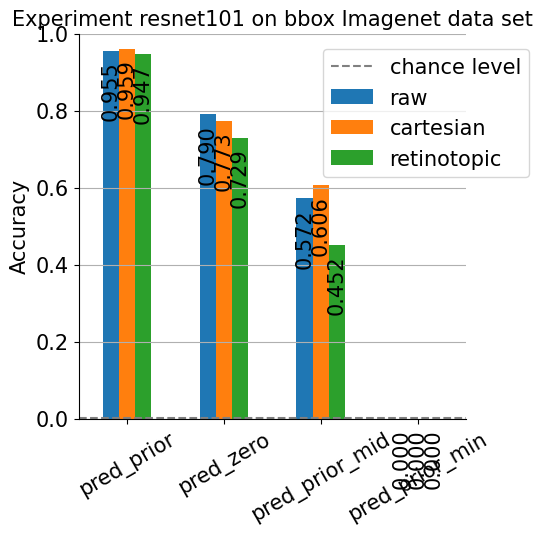

In [111]:
fig_width = 5
fontsize= 15

for model_data_set_type in [ 'bbox']:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    for model_name in  ['resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)
                
        df_acc = pd.DataFrame({pred: {label: accuracy_score(df_[pred], df_["label"])
                                            for label, df_ in zip(['raw', 'cartesian', 'retinotopic'], [df_raw, df, df_ret])} 
                               for pred in ['pred_prior', 'pred_zero', 'pred_prior_mid', 'pred_prior_min']})
        
        ax = df_acc.T.plot.bar(rot=30, figsize=(fig_width, fig_width), fontsize=fontsize)
        ax.set_ylim(0, 1)
        ax.hlines(xmin=-.5, xmax=7.5, y=1/1000, ls='--', ec='gray', label='chance level')
        # https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html
        for container in ax.containers: ax.bar_label(container, padding=-50, color='black', fontsize=fontsize, fmt='%.3f', rotation=90)
        plt.legend(bbox_to_anchor=(1.19, .60), loc='lower right', fontsize=fontsize)
        ax.grid(which='both', axis='y')
        for side in ['top', 'right'] :ax.spines[side].set_visible(False)
        ax.set_title(f'Experiment {model_name} on {model_data_set_type} Imagenet data set', size=fontsize)
        ax.set_ylabel('Accuracy', size=fontsize)
        plt.show();

In [6]:
for model_data_set_type in ['full', 'bbox', 'raw']:
#for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    #for model_name in  ['resnet101']:
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(f'{model_name=}')    
        print(50*'.')

        for do_polar in [False, True]:
            
            args.do_polar = do_polar 

            if do_polar and model_data_set_type =='raw':
                break
            print(f'{args.do_polar=}')
            print(50*'.')


            df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + f'_map_paper.parquet'

            results = pd.read_parquet(df_filename)
            
            print(results['likelihood_in_mean'].mean(), 'likelihood_in_mean')
            print(results['likelihood_out_mean'].mean(), 'likelihood_out_mean')
            print(results['likelihood_in_mean'].mean()/results['likelihood_out_mean'].mean(), 'likelihood ratio')
            print(results['likelihood_in_max'].mean(), 'likelihood_in_max')
            print(results['likelihood_out_max'].mean(), 'likelihood_out_max')
            
            
            print(results['mid_point'].mean(), 'mid_point')
            print(results['in_point'].mean(), 'in_point')
            print(results['ext_point'].mean(), 'ext_point')
    
            mean_Iou = read_IoU(results['Iou'])
            print(mean_Iou[0], 'mean IoU')

            best_Iou = get_best_Iou(results['Iou'], np.argmax(mean_Iou[0]))
            
            for test_tresh in [0, 0.1, 0.2, 0.3, 0.4, 0.5]:
                inpel = 0
                for i, j in enumerate(results['likelihood_in_max']):
                    #print(i, j, results['max_in_heat'][i] , '>', results['max_out_heat'][i])
                    if best_Iou[i] > test_tresh and results['label'][i] == results['pred_prior'][i]:
                        inpel += 1
                print(inpel/len(results['likelihood_in_max']), f'GT-known : {test_tresh}')
        
            
            
            print(results['PG'].mean(), 'PG')
        


model_data_set_type='full'
model_name='resnet18'
..................................................
args.do_polar=False
..................................................
0.3714438496416296 likelihood_in_mean
0.0595554125142733 likelihood_out_mean
6.236945291120397 likelihood ratio
0.7987538706136557 likelihood_in_max
0.48910085081157534 likelihood_out_max
0.5841448095604179 mid_point
0.17236142715525 in_point
0.004042761423624757 ext_point
{0: 0.43859358797515235, 1: 0.4517319103785365, 2: 0.42652148384835276, 3: 0.4085174375778342, 4: 0.394010435695397, 5: 0.3818202846791901, 6: 0.3712148158779485, 7: 0.3614352974024676, 8: 0.3526398727255121, 9: 0.3443629746464467, 10: 0.33646350011468673, 11: 0.3289148111027125, 12: 0.3217745316985921, 13: 0.3146046393371983, 14: 0.3077730483720042, 15: 0.30105371376121287, 16: 0.2944404373965996, 17: 0.2877975158725346, 18: 0.2812657510821345, 19: 0.2748000605833659, 20: 0.26829836682468955, 21: 0.2616548713752532, 22: 0.2549923442741082, 23: 0.24

model_data_set_type='full'
..................................................
df_filename='cached_data/2024-05-24_full_resnet18_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet18_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet18_cartesian_map_paper.parquet'


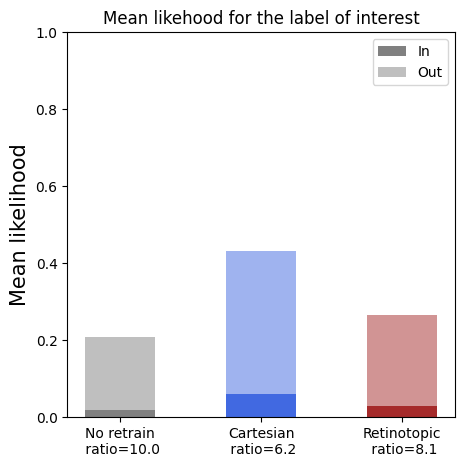

..................................................
df_filename='cached_data/2024-05-24_full_resnet50_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet50_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet50_cartesian_map_paper.parquet'


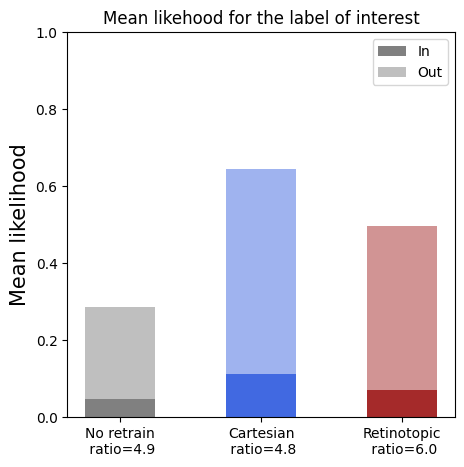

..................................................
df_filename='cached_data/2024-05-24_full_resnet101_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet101_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_paper.parquet'


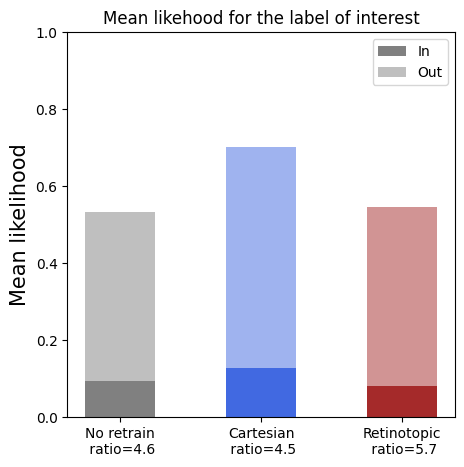

model_data_set_type='bbox'
..................................................
df_filename='cached_data/2024-05-24_bbox_resnet18_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet18_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet18_cartesian_map_paper.parquet'


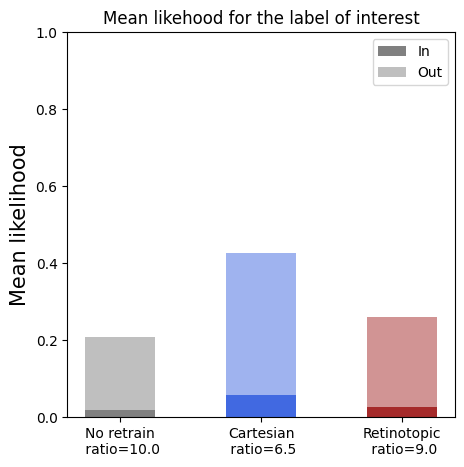

..................................................
df_filename='cached_data/2024-05-24_bbox_resnet50_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet50_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet50_cartesian_map_paper.parquet'


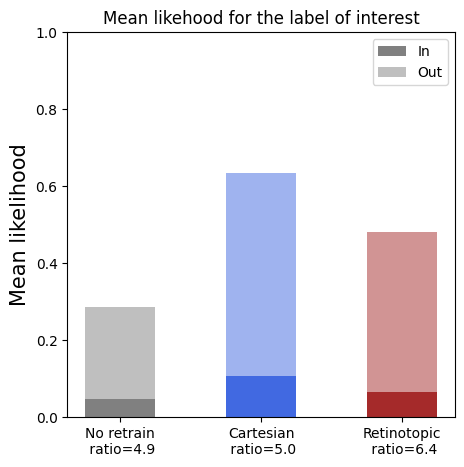

..................................................
df_filename='cached_data/2024-05-24_bbox_resnet101_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet101_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_paper.parquet'


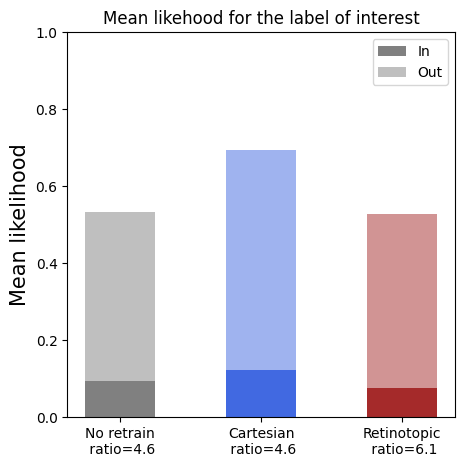

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# data from https://allisonhorst.github.io/palmerpenguins/
 

#for model_data_set_type in ['bbox']:
for model_data_set_type in ['full', 'bbox']:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    #for model_name in  ['resnet101']:
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        below, above, ratio = [], [], []
        df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)

        for df_ in [df_raw, df, df_ret]:

            below.append(df_['likelihood_out_mean'].mean())
            above.append(df_['likelihood_in_mean'].mean())
            ratio.append(df_['likelihood_in_mean'].mean()/df_['likelihood_out_mean'].mean())

        weight_counts = {
            "In": np.array(below),
            "Out": np.array(above),
        }
        
        species = (
            f"No retrain\n ratio={ratio[0]:.1f}",
            f"Cartesian\n ratio={ratio[1]:.1f}",
            f"Retinotopic\n ratio={ratio[2]:.1f}",
        )
        
        width = 0.5
        
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        bottom = np.zeros(3)
        alpha = 1
        for boolean, weight_count in weight_counts.items():
            p = ax.bar(species, weight_count, width, label=boolean, bottom=bottom, alpha=alpha, color=['grey', 'royalblue', 'brown'])
            bottom += weight_count
            alpha -= .5
        
        ax.set_ylim(0, 1)
        ax.set_title("Mean likehood for the label of interest")
        ax.legend(loc="upper right")
        ax.set_ylabel(f"Mean likelihood", size=15)
        #ax.set_xlabel(f"Ratio In / Out", size=15)
        #ax.axhline(y=0.5, xmin=0, ls='--', color='black', alpha=.5, xmax=5)
        plt.show()
        if False:
            to_save(fig, 'fig-ratio_paper')

model_data_set_type='full'
..................................................
df_filename='cached_data/2024-05-24_full_resnet18_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet18_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet18_cartesian_map_paper.parquet'
..................................................
df_filename='cached_data/2024-05-24_full_resnet50_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet50_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet50_cartesian_map_paper.parquet'
..................................................
df_filename='cached_data/2024-05-24_full_resnet101_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet101_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_paper.parquet'
model_data_set_type='bbox'
..................................................
df_filename='cached_data/2024-05-24_bbox

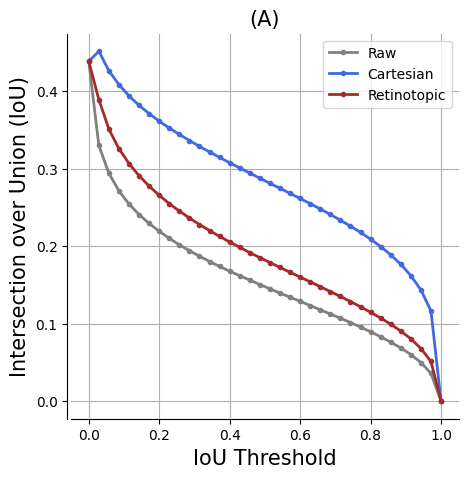

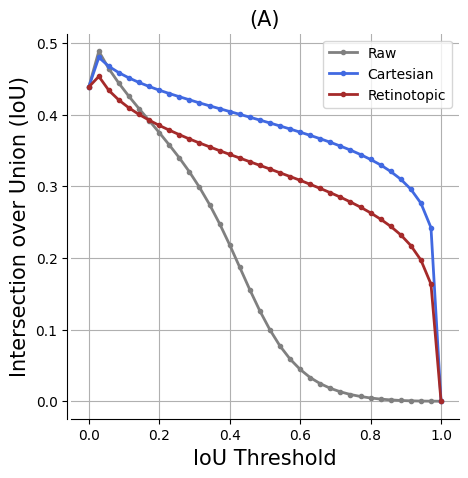

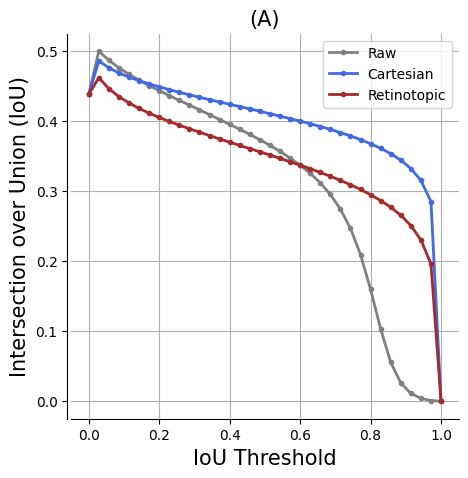

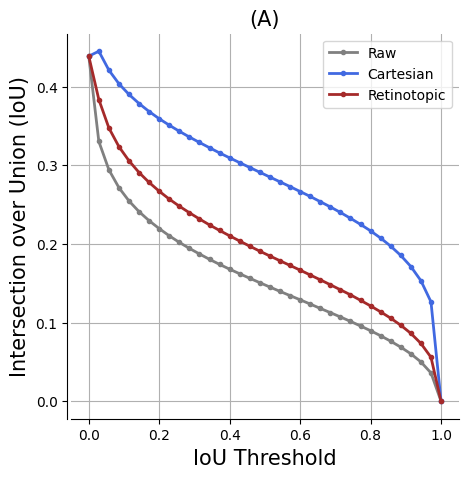

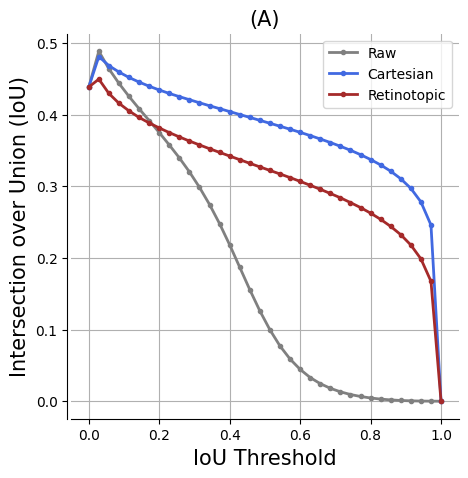

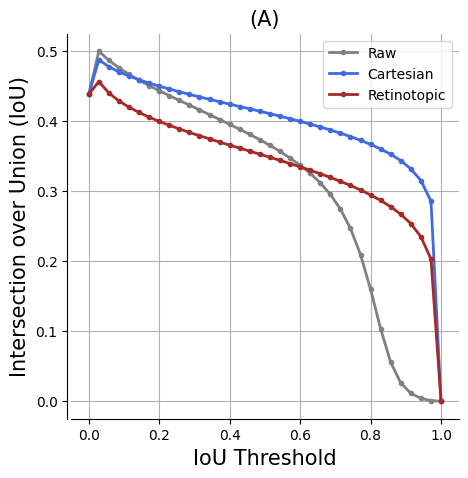

In [8]:
for model_data_set_type in ['full', 'bbox']:
#for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    #for model_name in  ['resnet101']:
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)


        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        
        for df_, label, color in zip([df_raw, df, df_ret], ['Raw', 'Cartesian', 'Retinotopic'], ['grey', 'royalblue', 'brown']):
        
            mean_Iou, list_Iou = read_IoU(df_['Iou'])
        
        
            ax.plot(np.linspace(0, 1,36), list_Iou, lw=2, marker='.', label=label, color=color)
            ax.set_xlabel(f"IoU Threshold", size=15)
            ax.set_ylabel(f"Intersection over Union (IoU)", size=15)
            ax.spines['left'].set_position(('axes', -0.01))
            #ax.set_yscale("logit", one_half="1/2", use_overline=True)
            ax.grid(which='both')
            ax.legend()
            for side in ['top', 'right'] :ax.spines[side].set_visible(False)
            #ax.set_title(f'{model_data_set_type}, {model_name}', size=15);
            #ax.set_title(f'(A)', size=15);
            if False:
                to_save(fig, 'fig-IoU_paper')

model_data_set_type='full'
..................................................
df_filename='cached_data/2024-05-24_full_resnet18_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet18_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet18_cartesian_map_paper.parquet'
..................................................
df_filename='cached_data/2024-05-24_full_resnet50_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet50_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet50_cartesian_map_paper.parquet'
..................................................
df_filename='cached_data/2024-05-24_full_resnet101_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet101_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_paper.parquet'
model_data_set_type='bbox'
..................................................
df_filename='cached_data/2024-05-24_bbox

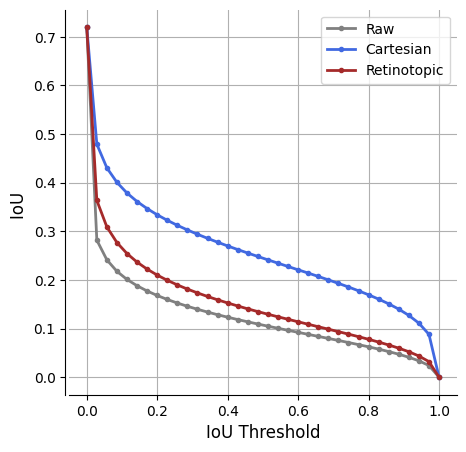

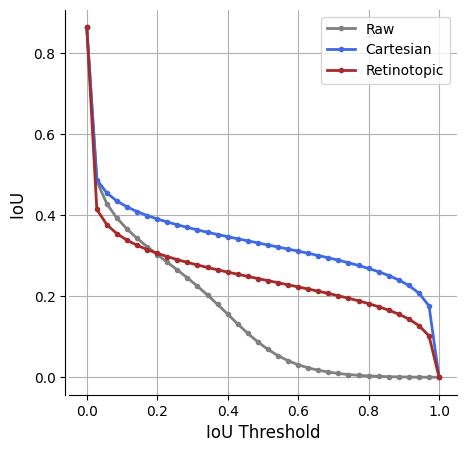

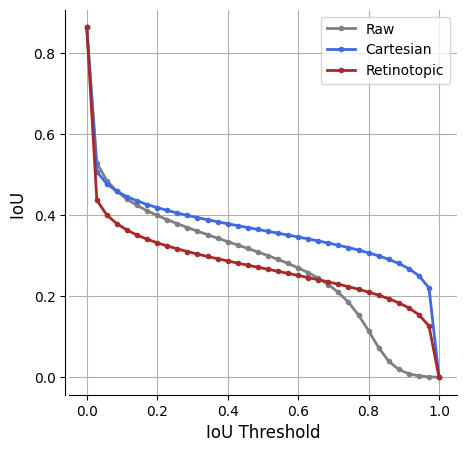

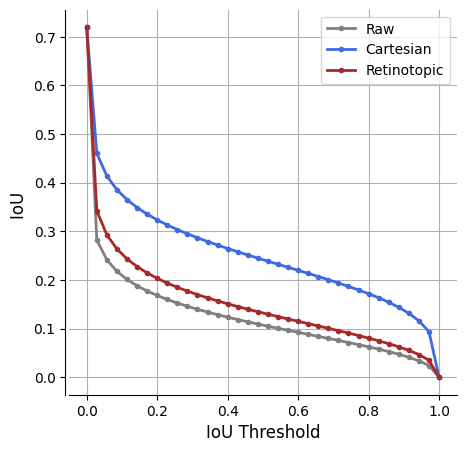

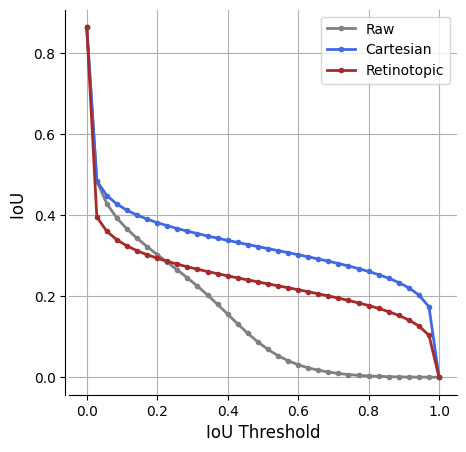

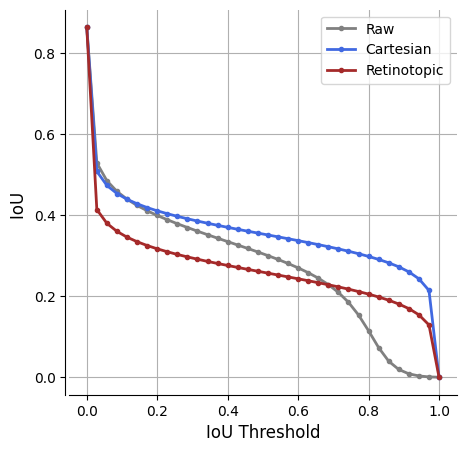

In [9]:
for model_data_set_type in ['full', 'bbox']:
#for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    #for model_name in  ['resnet101']:
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)


        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        
        for df_, label, color in zip([df_raw, df, df_ret], ['Raw', 'Cartesian', 'Retinotopic'], ['grey', 'royalblue', 'brown']):
        
            mean_Iou, list_Iou = read_IoU(df_['Iou_cam'])
        
        
            ax.plot(np.linspace(0, 1, len(list_Iou)), list_Iou, lw=2, marker='.', label=label, color=color)
            ax.set_xlabel(f"IoU Threshold", size=12)
            ax.set_ylabel(f"IoU ", size=12)
            ax.spines['left'].set_position(('axes', -0.01))
            #ax.set_yscale("logit", one_half="1/2", use_overline=True)
            ax.grid(which='both')
            ax.legend()
            for side in ['top', 'right'] :ax.spines[side].set_visible(False)
            #axs[0].set_title(f'Average values of the accuracy for different parameters :', size=10);
            

model_data_set_type='full'
..................................................
df_filename='cached_data/2024-05-24_full_resnet18_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet18_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet18_cartesian_map_paper.parquet'
[0.7433164311144675, 0.6660049627791563, 0.5863847232711188, 0.49153090948322364, 0.40882511597799115, 0.3154385586363146, 0.21355054482684216, 0.14495630596612363, 0.08652497572553673, 0.03836444060847988]
[0.9222785629517747, 0.8137015859315999, 0.7127198187506742, 0.5959218901715395, 0.49694681195382456, 0.3862121048656813, 0.26425720142410186, 0.18215557233790053, 0.11146833531125257, 0.050145646779587875]
[0.862401553565649, 0.7629949293343403, 0.66917682597907, 0.5601035710432625, 0.4667170137015859, 0.36256338332074656, 0.24800949401229905, 0.17063329377494876, 0.10391628007336282, 0.04660696946811954]
..................................................
df_filename='cached_d

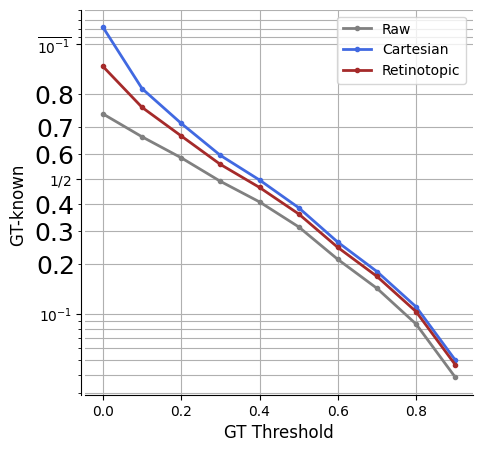

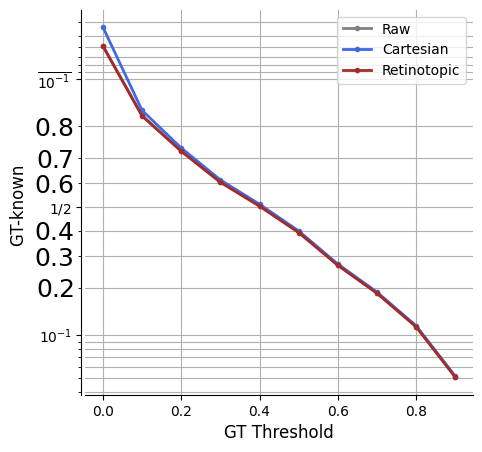

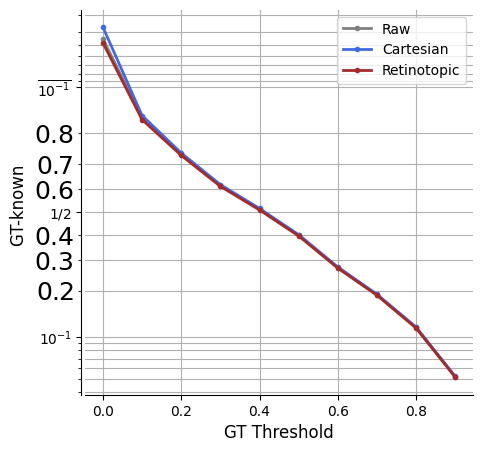

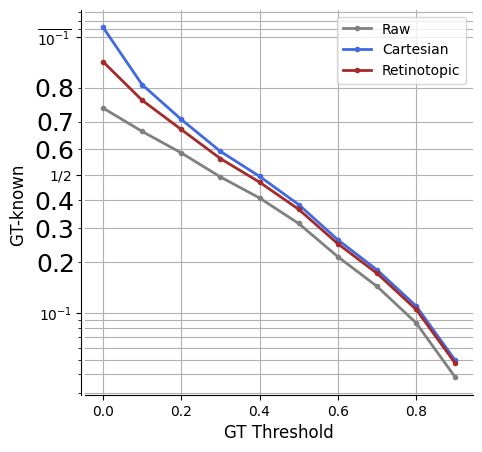

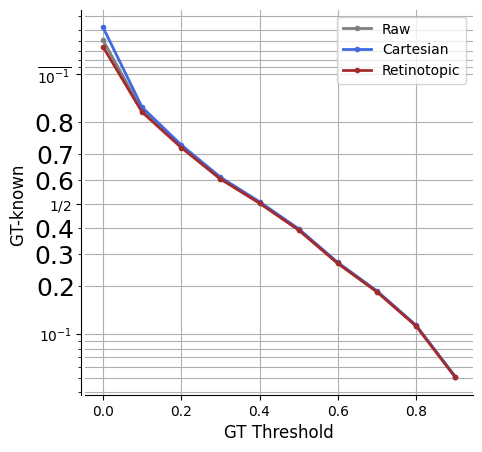

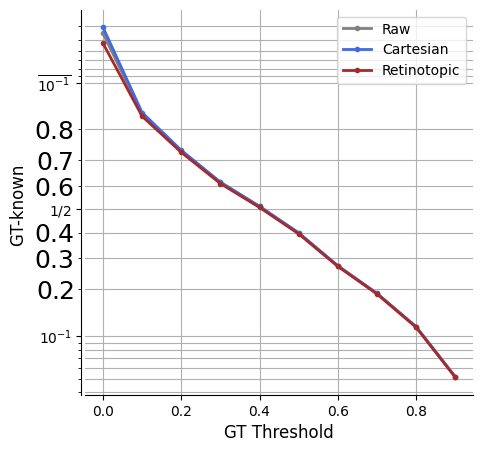

In [10]:
for model_data_set_type in ['full', 'bbox']:
#for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    #for model_name in  ['resnet101']:
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)

        GT = {}
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        
        for df_, label, color in zip([df_raw, df, df_ret], ['Raw', 'Cartesian', 'Retinotopic'], ['grey', 'royalblue', 'brown']):
            GT[label] = []
            for test_tresh in np.linspace(0, 0.9, 10):
                inpel = 0
                for i, j in enumerate(df_['likelihood_in_max']):
                    if best_Iou[i] > test_tresh and df_['label'][i] == df_['pred_prior'][i]:
                        inpel += 1
                GT[label].append(inpel/len(df_['likelihood_in_max']))
        
            print(GT[label])
            ax.plot(np.asarray(np.linspace(0, 0.9, 10)), GT[label], lw=2, marker='.', label=label, color=color)
            ax.set_xlabel(f"GT Threshold", size=12)
            ax.set_ylabel(f"GT-known ", size=12)
            ax.spines['left'].set_position(('axes', -0.01))
            ax.set_yscale("logit", one_half="1/2", use_overline=True)
            ax.grid(which='both')
            ax.legend()
            for side in ['top', 'right'] :ax.spines[side].set_visible(False)


In [146]:
df_filename_distance = f"{data_cache}/get_distance_to_plot_imagenet.parquet"
results = pd.read_parquet(df_filename_distance)
distance_plot = np.concatenate([np.zeros(len(results['Distance_0'])), np.asarray(results['Distance_0']), np.asarray(results['Distance_1'])])
distance_plot = normalize_array(distance_plot)

model_data_set_type='bbox'
..................................................
df_filename='cached_data/2024-05-24_bbox_resnet101_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet101_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_paper.parquet'


/tmp/ipykernel_1962/822015466.py:22: RuntimeWarning: Mean of empty slice.
  new_likelihood_plot.append(likelihood_plot[np.where(distance_plot > i)].mean())
/home/jnjer/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


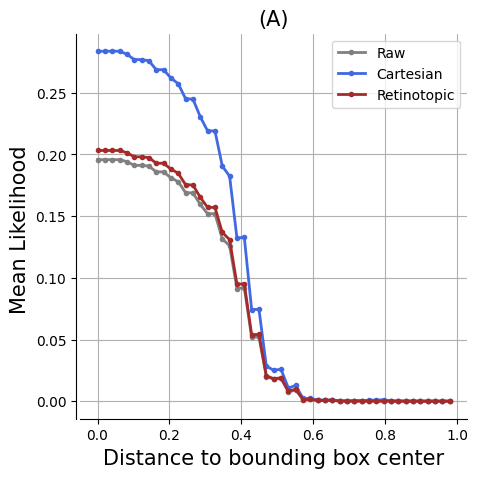

In [147]:
for model_data_set_type in [ 'bbox']:
#for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    for model_name in  ['resnet101']:
    #for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        
        for df_, label, color in zip([df_raw, df, df_ret], ['Raw', 'Cartesian', 'Retinotopic'], ['grey', 'royalblue', 'brown']):
            list_dist = []
            
            likelihood_plot = np.concatenate([np.array(df_['likelihood_prior']), np.array(df_['likelihood_prior_mid']), np.array(df_['likelihood_prior_min'])])
            #likelihood_plot = normalize_array(likelihood_plot)
            
            new_likelihood_plot = []
            for i in np.linspace(0, 1, 50 ):
                new_likelihood_plot.append(likelihood_plot[np.where(distance_plot > i)].mean()) 
        
        
        
            ax.plot(np.linspace(0, 1, 50 ), new_likelihood_plot, lw=2, marker='.', label=label, color=color)
            ax.set_xlabel(f"Distance to bounding box center", size=15)
            ax.set_ylabel(f"Mean Likelihood ", size=15)
            ax.spines['left'].set_position(('axes', -0.01))
        
            ax.grid(which='both')
            ax.legend()
            for side in ['top', 'right'] :ax.spines[side].set_visible(False)
            ax.set_title(f'(A)', size=15);

            if False:
                to_save(fig, 'fig-distance_box')
                    
        


model_data_set_type='full'
..................................................
df_filename='cached_data/2024-05-24_full_resnet18_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet18_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet18_cartesian_map_paper.parquet'
0.08217882475155709 9.958799296327925e-08
0.17000762435826158 7.689692216317212e-10
0.0930985247098767 1.7060591828155225e-09
..................................................
df_filename='cached_data/2024-05-24_full_resnet50_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet50_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet50_cartesian_map_paper.parquet'
0.10420201528173977 0.00012711566523648798
0.2485941685278592 1.6153680348907073e-07
0.18333903692783426 7.274613267327368e-08
..................................................
df_filename='cached_data/2024-05-24_full_resnet101_retino_map_paper.parquet'
df_filename='cached_data

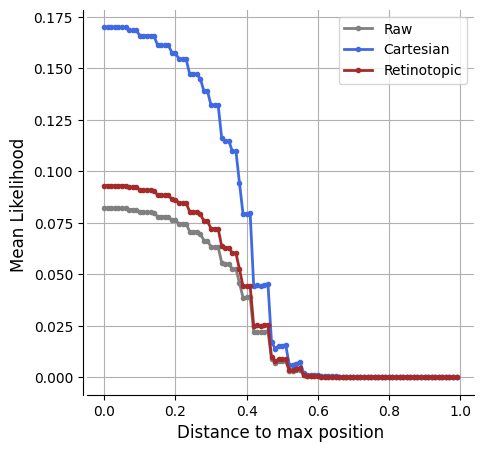

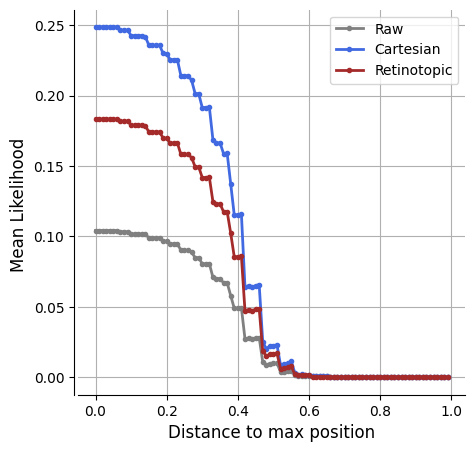

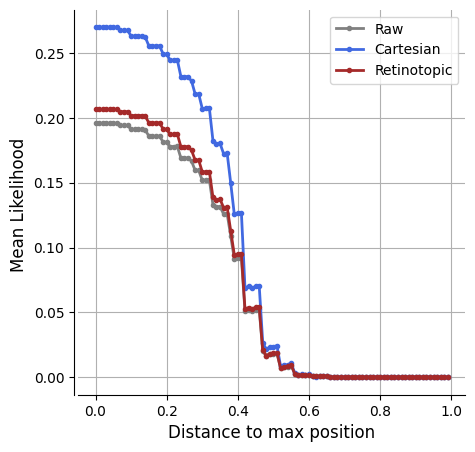

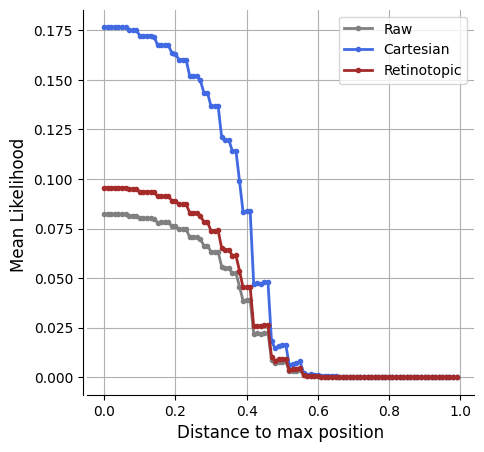

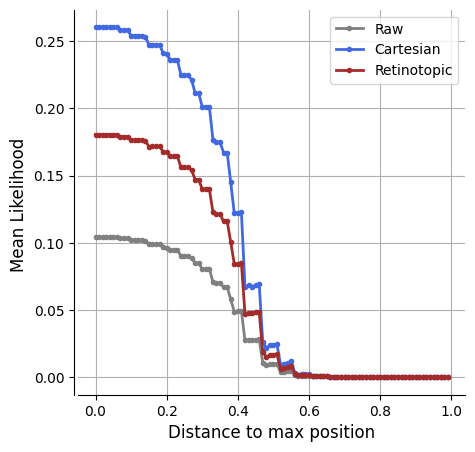

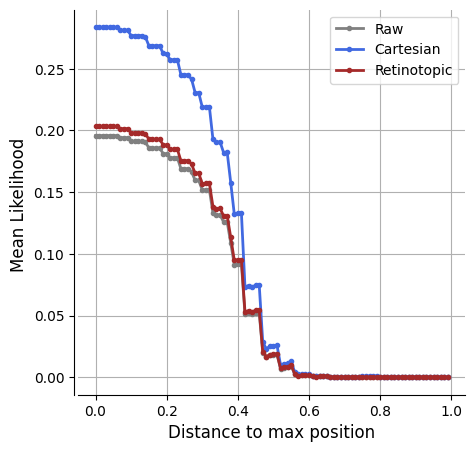

In [149]:
for model_data_set_type in ['full', 'bbox']:
#for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    #for model_name in  ['resnet101']:
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        
        for df_, label, color in zip([df_raw, df, df_ret], ['Raw', 'Cartesian', 'Retinotopic'], ['grey', 'royalblue', 'brown']):

            #distance_plot = np.concatenate([np.zeros(len(df_['Distance_0'])), np.asarray(df_['Distance_0']), np.asarray(df_['Distance_1'])])
            #distance_plot = normalize_array(distance_plot)
            
            list_dist = []
            
            likelihood_plot = np.concatenate([np.array(df_['likelihood_prior']), np.array(df_['likelihood_prior_mid']), np.array(df_['likelihood_prior_min'])])

            
            
            new_likelihood_plot = []
            for i in np.linspace(0, .99, 100 ):
                new_likelihood_plot.append(likelihood_plot[np.where(distance_plot > i)].mean()) 
            print(max(new_likelihood_plot), min(new_likelihood_plot))
        
        
        
            ax.plot(np.linspace(0, .99, 100 ), new_likelihood_plot, lw=2, marker='.', label=label, color=color)
            ax.set_xlabel(f"Distance to max position", size=12)
            ax.set_ylabel(f"Mean Likelihood ", size=12)
            ax.spines['left'].set_position(('axes', -0.01))
        
            ax.grid(which='both')
            ax.legend()
            for side in ['top', 'right'] :ax.spines[side].set_visible(False)
            #axs[0].set_title(f'Average values of the accuracy for different parameters :', size=10);
                    
        


model_data_set_type='full'
..................................................
df_filename='cached_data/2024-05-24_full_resnet18_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet18_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet18_cartesian_map_paper.parquet'
0.0832187707080281 3.1152292536350425e-05
0.1722615429407284 1.1899873074838751e-05
0.09439657734934592 1.2667047133368969e-05
..................................................
df_filename='cached_data/2024-05-24_full_resnet50_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_full_resnet50_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet50_cartesian_map_paper.parquet'
0.10534971125627164 0.0003904193511577968
0.25086146165288387 3.3436192552471766e-06
0.18582797194606293 1.724022992988239e-06
..................................................
df_filename='cached_data/2024-05-24_full_resnet101_retino_map_paper.parquet'
df_filename='cached_dat

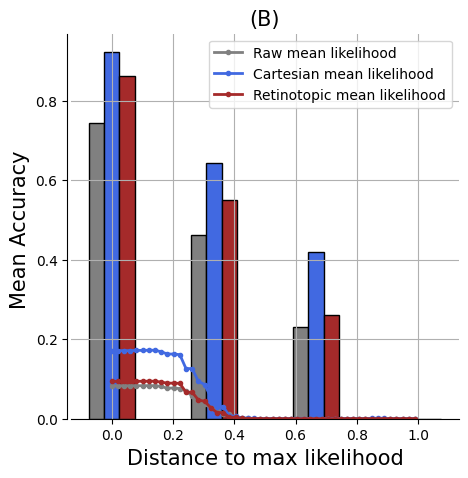

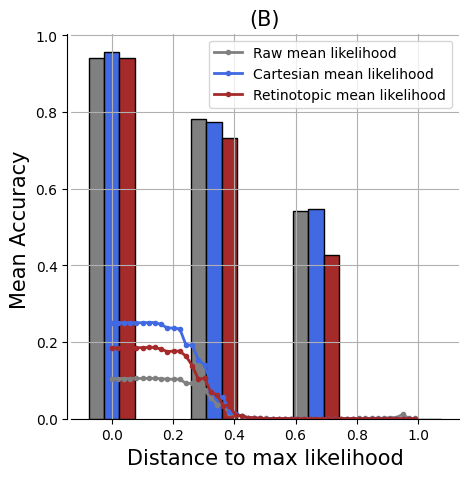

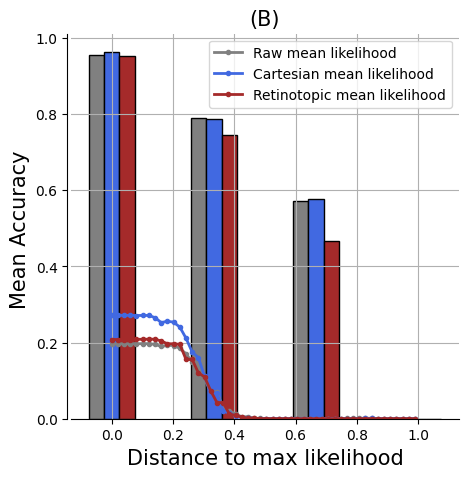

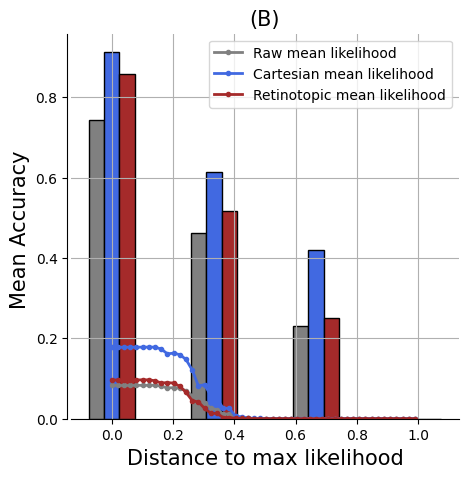

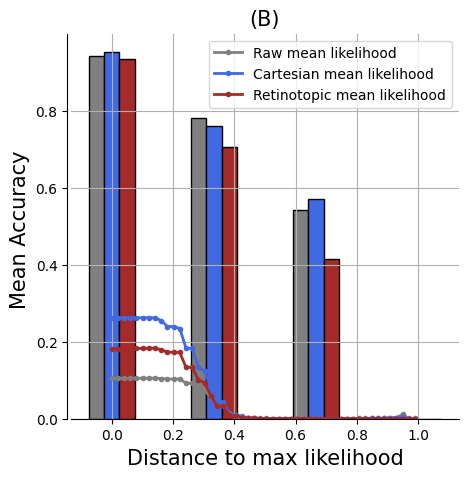

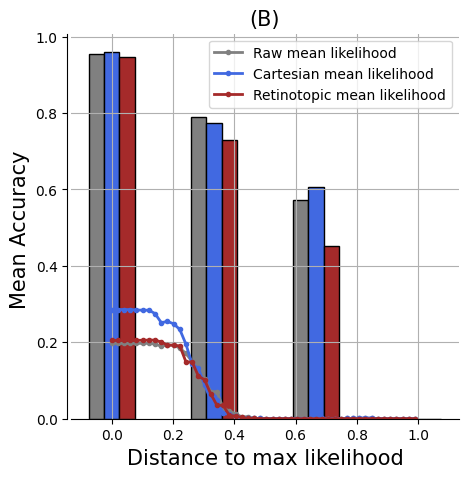

In [152]:
for model_data_set_type in ['full', 'bbox']:
#for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    #for model_name in  ['resnet101']:
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        
        for df_, label, color in zip([df_raw, df, df_ret], ['Raw', 'Cartesian', 'Retinotopic'], ['grey', 'royalblue', 'brown']):
            
            
            list_dist = []
            
            distance_plot = np.concatenate([np.zeros(len(df_['Distance_0'])), np.asarray(df_['Distance_0']), np.asarray(df_['Distance_1'])])
            distance_plot = normalize_array(distance_plot)
            likelihood_plot = np.concatenate([np.array(df_['likelihood_prior']), np.array(df_['likelihood_prior_mid']),  np.array(df_['likelihood_prior_min'])])

            
            new_likelihood_plot = []
            for i in np.linspace(0, .99, 50 ):
                new_likelihood_plot.append(likelihood_plot[np.where(distance_plot > i)].mean()) 
            print(max(new_likelihood_plot), min(new_likelihood_plot))

        
            ax.plot(np.linspace(0, .99, 50 ), new_likelihood_plot, lw=2, marker='.', label=label+' mean likelihood', color = color)
            ax.set_xlabel(f"Distance to max likelihood", size=15)
            ax.set_ylabel(f"Mean Accuracy ", size=15)
            ax.spines['left'].set_position(('axes', -0.01))
        
            ax.grid(which='both')
            ax.legend()
            for side in ['top', 'right'] :ax.spines[side].set_visible(False)
            #axs[0].set_title(f'Average values of the accuracy for different parameters :', size=10);
                
        df_acc = pd.DataFrame({pred: {label: accuracy_score(df_[pred], df_["label"])
                                            for label, df_ in zip(['raw', 'cartesian', 'retinotopic'], [df_raw, df, df_ret])} 
                               for pred in ['pred_prior', 'pred_zero', 'pred_prior_mid', 'pred_prior_min']})
    
        ax.set_title(f'(B)', size=15);
        N = 4
        ind = np.arange(N)  * 7 
        ind = np.linspace(0,1,N)
        width = 0.05
          
        xvals = np.asarray(df_acc.T['raw'])
        bar1 = plt.bar(ind-width, xvals, width, color = 'gray', edgecolor='black') 
          
        yvals = np.asarray(df_acc.T['cartesian'])
        bar2 = plt.bar(ind, yvals, width, color='royalblue', edgecolor='black')  
          
        zvals = np.asarray(df_acc.T['retinotopic'])
        bar3 = plt.bar(ind+width, zvals, width, color = 'brown', edgecolor='black') 

if False:
    to_save(fig, 'fig-distance_accuracy_paper')

model_data_set_type='bbox'
..................................................
df_filename='cached_data/2024-05-24_bbox_resnet101_retino_map_paper.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet101_cartesian_map_paper.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_paper.parquet'
0.24912384447173047 0.0001851713313953951
-2.6885855099681346 0.7413199234168241 Raw
0.33735628026006637 0.00016040325863286853
-2.0154803801674506 0.744548917239483 Cartesian
0.27745027700006036 3.3757314668037e-05
-2.3314998314830695 0.7358270621488262 Retinotopic


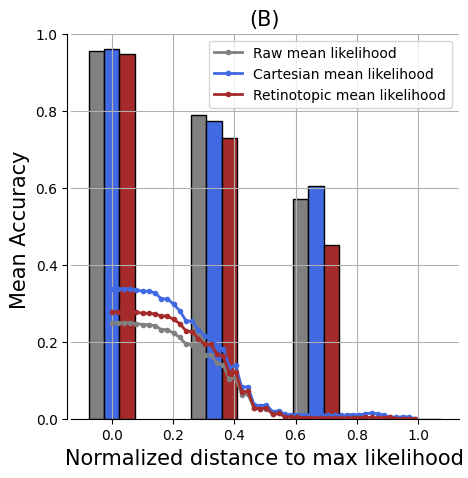

In [139]:
for model_data_set_type in ['bbox']:
#for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    for model_name in  ['resnet101']:
    #for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas(model_data_set_type, model_name)

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        
        for df_, label, color in zip([df_raw, df, df_ret], ['Raw', 'Cartesian', 'Retinotopic'], ['grey', 'royalblue', 'brown']):

            
            distance_plot = np.concatenate([np.zeros(len(df_['Distance_0'])), np.asarray(df_['Distance_0']), np.asarray(results['Distance_0']), np.asarray(results['Distance_1']), np.asarray(df_['Distance_1'])])
            distance_plot = normalize_array(ddistance_plot)
            likelihood_plot = np.concatenate([np.array(df_['likelihood_prior']), np.array(df_['likelihood_prior_mid']),  np.array(df_['mid_point']), np.array(df_['ext_point']), np.array(df_['likelihood_prior_min'])])
            
            new_likelihood_plot = []
            for i in np.linspace(0, .99, 50 ):
                new_likelihood_plot.append(likelihood_plot[np.where(distance_plot > i)].mean()) 
            print(max(new_likelihood_plot), min(new_likelihood_plot))

            coefficients = np.polyfit(np.array(new_likelihood_plot), np.linspace(0, .99, 50 ), 1)
            slope = coefficients[0]
            intercept = coefficients[1]
            print(slope, intercept, label)
        
        
            ax.plot(np.linspace(0, .99, 50 ), new_likelihood_plot, lw=2, marker='.', label=label+' mean likelihood', color = color)
            ax.set_xlabel(f"Normalized distance to max likelihood", size=15)
            ax.set_ylabel(f"Mean Accuracy ", size=15)
            ax.spines['left'].set_position(('axes', -0.01))
        
            ax.grid(which='both')
            ax.legend()
            for side in ['top', 'right'] :ax.spines[side].set_visible(False)
            #axs[0].set_title(f'Average values of the accuracy for different parameters :', size=10);
                
    df_acc = pd.DataFrame({pred: {label: accuracy_score(df_[pred], df_["label"])
                                        for label, df_ in zip(['raw', 'cartesian', 'retinotopic'], [df_raw, df, df_ret])} 
                           for pred in ['pred_prior', 'pred_zero', 'pred_prior_mid', 'pred_prior_min']})

    ax.set_title(f'(B)', size=15);
    N = 4
    ind = np.arange(N)  * 7 
    ind = np.linspace(0,1,N)
    width = 0.05
      
    xvals = np.asarray(df_acc.T['raw'])
    bar1 = plt.bar(ind-width, xvals, width, color = 'gray', edgecolor='black') 
      
    yvals = np.asarray(df_acc.T['cartesian'])
    bar2 = plt.bar(ind, yvals, width, color='royalblue', edgecolor='black')  
      
    zvals = np.asarray(df_acc.T['retinotopic'])
    bar3 = plt.bar(ind+width, zvals, width, color = 'brown', edgecolor='black') 
ax.set_ylim(0, 1)
if False:
    to_save(fig, 'fig-distance_accuracy_nozoom_paper')

In [16]:
def get_pandas_2(model_data_set_type, model_name):
    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, True) + f'_map_paper_test.parquet'

    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df_ret = pd.read_parquet(df_filename)


    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, False) + f'_map_paper_test.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df = pd.read_parquet(df_filename)

    df_filename = get_filename(data_cache, datetag, 'raw', model_name, False) + f'_map_paper_test.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df_raw = pd.read_parquet(df_filename)
    
        
    return df, df_ret, df_raw

model_data_set_type='bbox'
..................................................
df_filename='cached_data/2024-05-24_bbox_resnet101_retino_map_paper_test.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet101_cartesian_map_paper_test.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_paper_test.parquet'
0.420971478619458 0.09079747917430538
-0.39213168428927003 0.41875273823517395 Raw
0.5397095717413118 0.005026040133088827
-0.567685711266827 0.5567875928042724 Cartesian
0.4614838149204848 0.009060648269951344
-0.568952368575328 0.473534192252695 Retinotopic


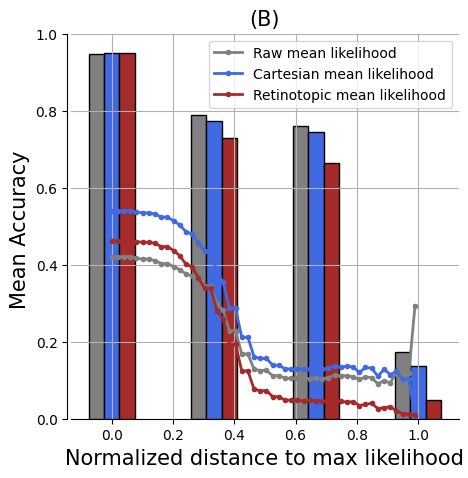

In [118]:
for model_data_set_type in ['bbox']:
#for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    for model_name in  ['resnet101']:
    #for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas_2(model_data_set_type, model_name)

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        
        for df_, label, color in zip([df_raw, df, df_ret], ['Raw', 'Cartesian', 'Retinotopic'], ['grey', 'royalblue', 'brown']):

            distance_plot = np.concatenate([np.zeros(len(results['Distance_0'])), np.asarray(results['Distance_0']),np.asarray(df_['Distance_0']), np.asarray(results['Distance_1'])])
            distance_plot = normalize_array(distance_plot)
            likelihood_plot = np.concatenate([np.array(df_['in_point']), np.array(df_['likelihood_prior_mid']),  np.array(df_['mid_point']), np.array(df_['likelihood_prior_min'])])
            
            new_likelihood_plot = []
            for i in np.linspace(0, .99, 50 ):
                new_likelihood_plot.append(likelihood_plot[np.where(distance_plot > i)].mean()) 
            print(max(new_likelihood_plot), min(new_likelihood_plot))

            coefficients = np.polyfit( np.linspace(0, .99, 50 ), np.array(new_likelihood_plot), 1)
            slope = coefficients[0]
            intercept = coefficients[1]
            print(slope, intercept, label)
        
        
            ax.plot(np.linspace(0, .99, 50 ), new_likelihood_plot, lw=2, marker='.', label=label+' mean likelihood', color = color)
            ax.set_xlabel(f"Normalized distance to max likelihood", size=15)
            ax.set_ylabel(f"Mean Accuracy ", size=15)
            ax.spines['left'].set_position(('axes', -0.01))
        
            ax.grid(which='both')
            ax.legend()
            for side in ['top', 'right'] :ax.spines[side].set_visible(False)
            #axs[0].set_title(f'Average values of the accuracy for different parameters :', size=10);
                
    df_acc = pd.DataFrame({pred: {label: accuracy_score(df_[pred], df_["label"])
                                        for label, df_ in zip(['raw', 'cartesian', 'retinotopic'], [df_raw, df, df_ret])} 
                           for pred in ['pred_prior','pred_zero', 'pred_prior_mid', 'pred_prior_min']})

    ax.set_title(f'(B)', size=15);
    N = 4
    ind = np.arange(N)  * 7 
    ind = np.linspace(0,1,N)
    width = 0.05
      
    xvals = np.asarray(df_acc.T['raw'])
    bar1 = plt.bar(ind-width, xvals, width, color = 'gray', edgecolor='black') 
      
    yvals = np.asarray(df_acc.T['cartesian'])
    bar2 = plt.bar(ind, yvals, width, color='royalblue', edgecolor='black')  
      
    zvals = np.asarray(df_acc.T['retinotopic'])
    bar3 = plt.bar(ind+width, zvals, width, color = 'brown', edgecolor='black') 
ax.set_ylim(0, 1)
if False:
    to_save(fig, 'fig-distance_accuracy_nozoom_paper')

In [27]:
df_filename_distance = f"{data_cache}/get_distance_to_plot_imagenet.parquet"
results = pd.read_parquet(df_filename_distance)


model_data_set_type='bbox'
..................................................
df_filename='cached_data/2024-05-24_bbox_resnet101_retino_map_paper_test.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet101_cartesian_map_paper_test.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_paper_test.parquet'


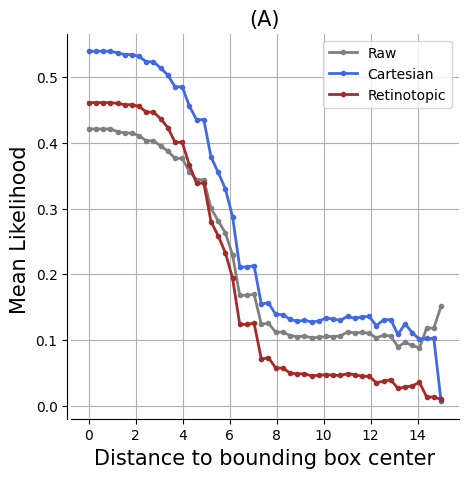

In [36]:
for model_data_set_type in [ 'bbox']:
#for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    for model_name in  ['resnet101']:
    #for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas_2(model_data_set_type, model_name)

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        
        for df_, label, color in zip([df_raw, df, df_ret], ['Raw', 'Cartesian', 'Retinotopic'], ['grey', 'royalblue', 'brown']):
            list_dist = []
            
            distance_plot = np.concatenate([np.zeros(len(results['Distance_0'])), np.asarray(results['Distance_0']),np.asarray(df_['Distance_0']), np.asarray(results['Distance_1'])])
            likelihood_plot = np.concatenate([np.array(df_['in_point']), np.array(df_['likelihood_prior_mid']),  np.array(df_['mid_point']), np.array(df_['likelihood_prior_min'])])
            likelihood_plot = normalize_array(likelihood_plot)
            
            new_likelihood_plot = []
            for i in np.linspace(0, 15, 50 ):
                new_likelihood_plot.append(likelihood_plot[np.where(distance_plot > i)].mean()) 
        
        
        
            ax.plot(np.linspace(0, 15, 50 ), new_likelihood_plot, lw=2, marker='.', label=label, color=color)
            ax.set_xlabel(f"Distance to bounding box center", size=15)
            ax.set_ylabel(f"Mean Likelihood ", size=15)
            ax.spines['left'].set_position(('axes', -0.01))
        
            ax.grid(which='both')
            ax.legend()
            for side in ['top', 'right'] :ax.spines[side].set_visible(False)
            ax.set_title(f'(A)', size=15);

            if False:
                to_save(fig, 'fig-distance_boxe')
                    
        


model_data_set_type='bbox'
..................................................
df_filename='cached_data/2024-05-24_bbox_resnet101_retino_map_paper_test.parquet'
df_filename='cached_data/2024-05-24_bbox_resnet101_cartesian_map_paper_test.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_map_paper_test.parquet'


/tmp/ipykernel_1962/3973779313.py:26: RuntimeWarning: Mean of empty slice.
  new_likelihood_plot.append(likelihood_plot[np.where(distance_plot > i)].mean())
/home/jnjer/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


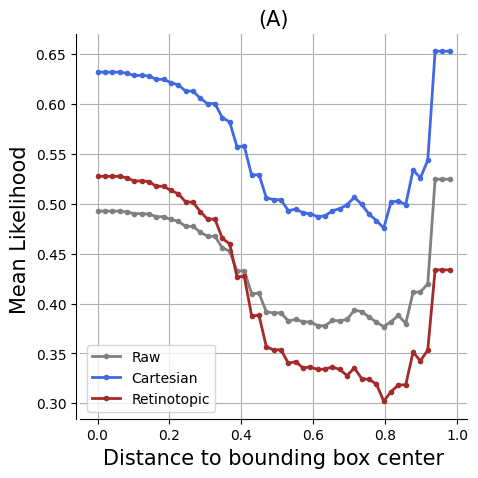

In [39]:
distance_plot = np.concatenate([np.zeros(len(results['Distance_0'])), np.asarray(results['Distance_0']), np.asarray(results['Distance_1'])])
distance_plot = normalize_array(distance_plot)

for model_data_set_type in [ 'bbox']:
#for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    for model_name in  ['resnet101']:
    #for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        df, df_ret, df_raw = get_pandas_2(model_data_set_type, model_name)

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        
        for df_, label, color in zip([df_raw, df, df_ret], ['Raw', 'Cartesian', 'Retinotopic'], ['grey', 'royalblue', 'brown']):
            list_dist = []
            
            
            likelihood_plot = np.concatenate([np.array(df_['in_point']), np.array(df_['mid_point']), np.array(df_['ext_point'])])
            #likelihood_plot = normalize_array(likelihood_plot)
            
            new_likelihood_plot = []
            for i in np.linspace(0, 1, 50 ):
                new_likelihood_plot.append(likelihood_plot[np.where(distance_plot > i)].mean()) 
        
        
        
            ax.plot(np.linspace(0, 1, 50 ), new_likelihood_plot, lw=2, marker='.', label=label, color=color)
            ax.set_xlabel(f"Distance to bounding box center", size=15)
            ax.set_ylabel(f"Mean Likelihood ", size=15)
            ax.spines['left'].set_position(('axes', -0.01))
        
            ax.grid(which='both')
            ax.legend()
            for side in ['top', 'right'] :ax.spines[side].set_visible(False)
            ax.set_title(f'(A)', size=15);

            if False:
                to_save(fig, 'fig-distance_boxe')
                    
        
